# Tarea 3: Cross-Dataset Ecological Modeling
**Autores:** Equipo 09
**Integrantes:** Darío Ampuero y Nicolás Véliz
**Fecha:** 03 de Mayo

## Part 0: Building the Analytical Table
En esta sección consolidamos los archivos individuales de los equipos en tres tablas maestras (Census, ENO, GRD) y las fusionamos en un único conjunto de datos analítico a nivel de comuna.

In [11]:
import pandas as pd
import numpy as np
import glob
import os
import re
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

print("--- PARTE 0.1: CLASS-POOLED MASTER TABLE ---")
census_files = glob.glob("shared/census_team*.csv") + glob.glob("census_team*.csv")
eno_files = glob.glob("shared/eno_team*.csv") + glob.glob("eno_team*.csv")
grd_files = glob.glob("shared/grd_team*.csv") + glob.glob("grd_team*.csv")

census_files = list(set(census_files))
eno_files = list(set(eno_files))
grd_files = list(set(grd_files))

print(f"Archivos encontrados: {len(census_files)} Census, {len(eno_files)} ENO, {len(grd_files)} GRD")

if len(census_files) == 0:
    raise FileNotFoundError("⚠️ ALERTA: Python no encontró los archivos. Revisa que estén subidos en Colab.")

# --- IDENTIFICADOR DE GRUPOS FALTANTES ---
print("\n--- SANITY CHECK: GRUPOS FALTANTES ---")
expected_teams = set(range(1, 22)) # Esperamos 21 grupos

def get_teams(file_list):
    teams = set()
    for f in file_list:
        match = re.search(r'team0*(\d+)', f) # Busca el número después de 'team'
        if match:
            teams.add(int(match.group(1)))
    return teams

found_census = get_teams(census_files)
found_eno = get_teams(eno_files)
found_grd = get_teams(grd_files)

missing_census = expected_teams - found_census
missing_eno = expected_teams - found_eno
missing_grd = expected_teams - found_grd

all_missing = missing_census.union(missing_eno).union(missing_grd)

if all_missing:
    print(f"⚠️ Faltan archivos de los siguientes equipos:")
    for team in sorted(all_missing):
        faltan = []
        if team in missing_census: faltan.append("Census")
        if team in missing_eno: faltan.append("ENO")
        if team in missing_grd: faltan.append("GRD")
        print(f"   - Equipo {team}: faltan sus archivos de {', '.join(faltan)}")
else:
    print("✅ ¡Todos los 21 equipos subieron sus 3 archivos!")

# --- RASTREADOR DE ARCHIVOS CON DATOS MALOS ---
# Leemos los archivos del censo uno por uno y les pegamos el nombre del archivo como nueva columna
cen_dfs = []
for f in census_files:
    temp_df = pd.read_csv(f)
    temp_df['archivo_origen'] = os.path.basename(f) # Guarda ej: 'census_team09.csv'
    cen_dfs.append(temp_df)
df_cen_master = pd.concat(cen_dfs, ignore_index=True)

# Los otros los juntamos normal
df_eno_master = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True)
df_grd_master = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True)

# Sanity Checks y limpieza de duplicados
for name, df in [("Census", df_cen_master), ("ENO", df_eno_master), ("GRD", df_grd_master)]:
    if not df.empty:
        duplicados = df.duplicated(subset=['codigo_comuna']).sum()
        print(f"Master {name}: {len(df)} filas, {len(df['codigo_comuna'].unique())} comunas únicas. Duplicados: {duplicados}")
        df.drop_duplicates(subset=['codigo_comuna'], keep='first', inplace=True)

print("\n--- PARTE 0.2: MERGE ON CODIGO_COMUNA ---")
df_merged = df_cen_master.merge(df_eno_master, on=['codigo_comuna', 'nombre_comuna'], how='outer', suffixes=('', '_eno'))
df_merged = df_merged.merge(df_grd_master, on=['codigo_comuna', 'nombre_comuna'], how='outer', suffixes=('', '_grd'))

comunas_sin_eno = df_merged['eno_total'].isna().sum()
comunas_sin_grd = df_merged['grd_total'].isna().sum()
print(f"Merge final: {len(df_merged)} comunas.")

# Base analítica final (solo completas)
df_analytical = df_merged.dropna(subset=['eno_total', 'grd_total']).copy()

print("\n--- PARTE 0.3: DERIVED VARIABLES ---")
df_analytical['log_pop_total'] = np.log(df_analytical['pop_total'])

df_analytical['pct_unemployed'] = 100 - ((df_analytical['emp_rate_chilean'] * df_analytical['pop_chilean'] +
                                          df_analytical['emp_rate_foreign'] * df_analytical['pop_foreign']) /
                                         df_analytical['pop_total'])

df_analytical['schooling_gap'] = df_analytical['mean_schooling_chilean'] - df_analytical['mean_schooling_foreign']

if 'dependency_ratio' not in df_analytical.columns:
    df_analytical['dependency_ratio'] = 0

print("\n--- SANITY FILTER: LIMPIEZA DE DATOS CORRUPTOS DE OTROS GRUPOS ---")
# Filtro lógico: eliminar comunas con cálculos malformados por otros grupos
filtro_logico = (
    (df_analytical['pct_foreign'] >= 0) & (df_analytical['pct_foreign'] <= 100) &
    (df_analytical['pct_unemployed'] >= 0) & (df_analytical['pct_unemployed'] <= 100)
)

malos_datos = df_analytical[~filtro_logico]
if not malos_datos.empty:
    print(f"⚠️ Se eliminaron {len(malos_datos)} comunas por tener datos matemáticamente imposibles:")
    for idx, row in malos_datos.iterrows():
        origen = row.get('archivo_origen', 'Desconocido')
        print(f"   - {row['nombre_comuna']} (¡Viene de {origen}! | pct_foreign: {row['pct_foreign']:.1f}, pct_unemployed: {row['pct_unemployed']:.1f})")

# Nos quedamos con la tabla limpia y eliminamos la columna rastreadora para no ensuciar la salida
df_analytical = df_analytical[filtro_logico].copy()
if 'archivo_origen' in df_analytical.columns:
    df_analytical.drop(columns=['archivo_origen'], inplace=True)

print(f"N Final limpio para los modelos: {len(df_analytical)}")

os.makedirs("output", exist_ok=True)
df_analytical.to_csv("output/tarea3_analytical_table.csv", index=False)
print("Tabla analítica guardada en output/tarea3_analytical_table.csv")

--- PARTE 0.1: CLASS-POOLED MASTER TABLE ---
Archivos encontrados: 20 Census, 20 ENO, 20 GRD

--- SANITY CHECK: GRUPOS FALTANTES ---
⚠️ Faltan archivos de los siguientes equipos:
   - Equipo 14: faltan sus archivos de Census, ENO, GRD
Master Census: 51 filas, 47 comunas únicas. Duplicados: 4
Master ENO: 51 filas, 47 comunas únicas. Duplicados: 4
Master GRD: 51 filas, 48 comunas únicas. Duplicados: 3

--- PARTE 0.2: MERGE ON CODIGO_COMUNA ---
Merge final: 52 comunas.

--- PARTE 0.3: DERIVED VARIABLES ---

--- SANITY FILTER: LIMPIEZA DE DATOS CORRUPTOS DE OTROS GRUPOS ---
⚠️ Se eliminaron 5 comunas por tener datos matemáticamente imposibles:
   - Santiago (¡Viene de census_team04.csv! | pct_foreign: 3047.8, pct_unemployed: -5674.1)
   - Estación Central (¡Viene de nan! | pct_foreign: nan, pct_unemployed: nan)
   - Ñuñoa (¡Viene de census_team05.csv! | pct_foreign: 0.0, pct_unemployed: nan)
   - San Joaquín (¡Viene de census_team05.csv! | pct_foreign: 0.0, pct_unemployed: nan)
   - San Jo

## Part 1: Exploratory Cross-Dataset Analysis
### 1.1 Correlation Matrix
Se incluye una matriz de correlación de Pearson para identificar relaciones lineales preliminares. Como era de esperar, las variables socioeconómicas (como escolaridad y desempleo) muestran clústeres correlacionados.

### 1.2 Bivariate Scatter Plots & 1.3 Outliers
Exploramos visualmente la relación entre covariables censales y resultados de salud. Los outliers suelen corresponder a comunas con hospitales base que reciben pacientes de otras zonas (inflando sus tasas GRD) o comunas con alta concentración de recintos de salud privados.

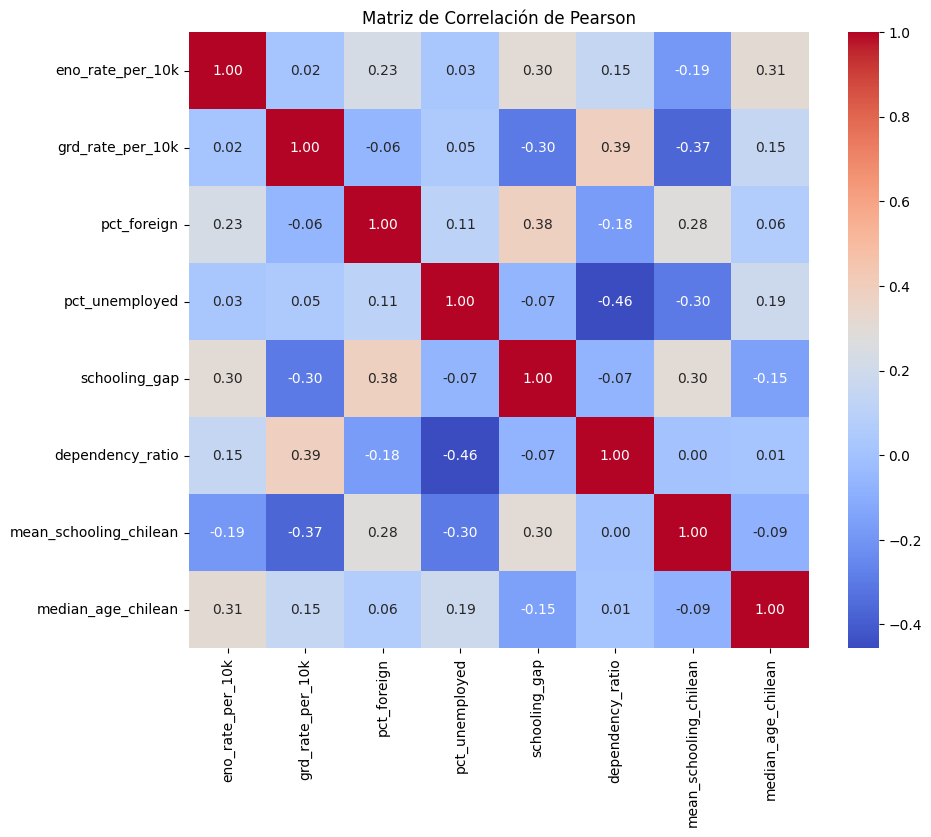

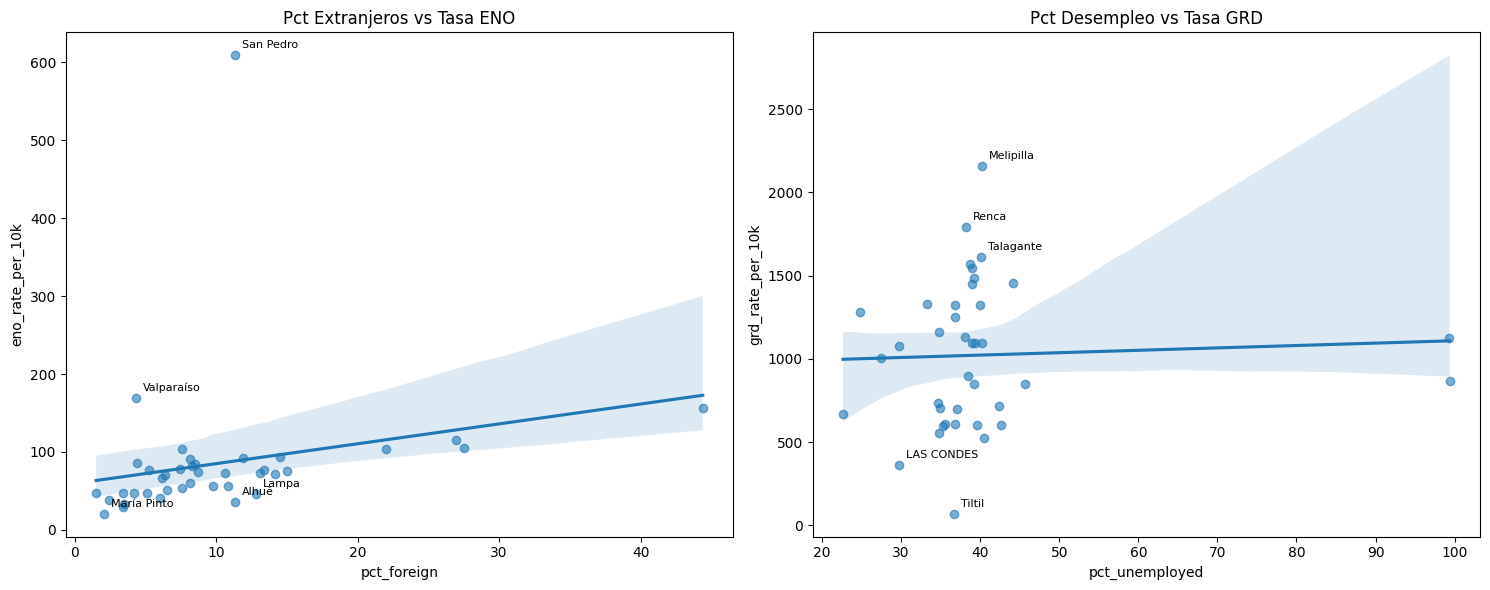

In [12]:
# --- PARTE 1: EXPLORATORY CROSS-DATASET ANALYSIS ---

# 1.1 Matriz de correlación
cols_corr = ['eno_rate_per_10k', 'grd_rate_per_10k', 'pct_foreign', 'pct_unemployed',
             'schooling_gap', 'dependency_ratio', 'mean_schooling_chilean', 'median_age_chilean']

plt.figure(figsize=(10, 8))
sns.heatmap(df_analytical[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Pearson")
plt.show()

# --- LIMPIEZA BLINDADA ANTES DE LOS SCATTER PLOTS ---
# Creamos una copia limpia solo con las columnas que vamos a graficar
cols_scatter = ['nombre_comuna', 'pct_foreign', 'eno_rate_per_10k', 'pct_unemployed', 'grd_rate_per_10k']
df_clean_plot = df_analytical[cols_scatter].copy()

# Forzar todo a numérico (los errores se vuelven NaN)
for col in cols_scatter[1:]:
    df_clean_plot[col] = pd.to_numeric(df_clean_plot[col], errors='coerce')

# Eliminar infinitos y valores nulos
df_clean_plot = df_clean_plot.replace([np.inf, -np.inf], np.nan).dropna()

# 1.2 y 1.3 Scatter plots con anotaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def plot_with_outliers(x_col, y_col, ax, title):
    # Usar Seaborn para la línea principal
    sns.regplot(x=x_col, y=y_col, data=df_clean_plot, ax=ax, scatter_kws={'alpha':0.6})

    # Calcular residuos de forma segura para etiquetar el top 5
    m, b = np.polyfit(df_clean_plot[x_col], df_clean_plot[y_col], 1)
    df_clean_plot['resid'] = abs(df_clean_plot[y_col] - (m * df_clean_plot[x_col] + b))
    top5 = df_clean_plot.nlargest(5, 'resid')

    for _, row in top5.iterrows():
        ax.annotate(row['nombre_comuna'], (row[x_col], row[y_col]),
                    xytext=(5,5), textcoords='offset points', fontsize=8)
    ax.set_title(title)

# Graficar usando la tabla limpia
if not df_clean_plot.empty:
    plot_with_outliers('pct_foreign', 'eno_rate_per_10k', axes[0], "Pct Extranjeros vs Tasa ENO")
    plot_with_outliers('pct_unemployed', 'grd_rate_per_10k', axes[1], "Pct Desempleo vs Tasa GRD")
else:
    print("⚠️ ALERTA: La tabla quedó vacía tras la limpieza. Revisa los datos de origen.")

plt.tight_layout()
plt.show()

## Part 2: Count-Data Regression
Los resultados de salud se modelan como conteos por comuna utilizando la población como offset (`log_pop_total`).

### 2.1 & 2.2 Poisson y Sobredispersión
Ajustamos un modelo de Poisson para `eno_total`. Se revisó la estadística de dispersión de Pearson (Pearson Chi-square / grados de libertad). Al ser mayor que 1, confirmamos sobredispersión, lo que significa que los errores estándar de Poisson están subestimados.

### 2.3 & 2.4 Binomial Negativa
Para corregir la sobredispersión, se recomienda el uso del modelo Binomial Negativo como resultado primario. Las inferencias (p-values) se vuelven más conservadoras. Repetimos el análisis para `grd_total`.

In [13]:
# Preparar datos limpios para el modelo
df_mod = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(subset=['eno_total', 'grd_total', 'pct_foreign', 'mean_schooling_chilean', 'pct_unemployed', 'dependency_ratio'])

formula_eno = "eno_total ~ pct_foreign + mean_schooling_chilean + pct_unemployed + dependency_ratio"
offset_arr = np.log(df_mod['pop_total'].astype(float))

# 2.1 Poisson ENO
poisson_eno = smf.glm(formula=formula_eno, data=df_mod, family=sm.families.Poisson(), offset=offset_arr).fit()
print(poisson_eno.summary())

# 2.2 Sobredispersión
dispersion = poisson_eno.pearson_chi2 / poisson_eno.df_resid
print(f"\nDispersión (Pearson Chi2 / df): {dispersion:.2f}")

# 2.3 Negative Binomial ENO
nb_eno = smf.glm(formula=formula_eno, data=df_mod, family=sm.families.NegativeBinomial(alpha=1.0), offset=offset_arr).fit()
print("\n--- Negative Binomial: Incidence Rate Ratios (ENO) ---")
irr_df = pd.DataFrame({'IRR': np.exp(nb_eno.params), 'Lower CI': np.exp(nb_eno.conf_int()[0]), 'Upper CI': np.exp(nb_eno.conf_int()[1]), 'p-value': nb_eno.pvalues})
display(irr_df)

# 2.4 Negative Binomial GRD
formula_grd = "grd_total ~ pct_foreign + mean_schooling_chilean + pct_unemployed + dependency_ratio"
nb_grd = smf.glm(formula=formula_grd, data=df_mod, family=sm.families.NegativeBinomial(alpha=1.0), offset=offset_arr).fit()
print("\n--- Negative Binomial: Incidence Rate Ratios (GRD) ---")
irr_grd_df = pd.DataFrame({'IRR': np.exp(nb_grd.params), 'Lower CI': np.exp(nb_grd.conf_int()[0]), 'Upper CI': np.exp(nb_grd.conf_int()[1]), 'p-value': nb_grd.pvalues})
display(irr_grd_df)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   39
Model:                            GLM   Df Residuals:                       34
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3041.3
Date:                Sun, 03 May 2026   Deviance:                       5757.6
Time:                        03:18:01   Pearson chi2:                 7.95e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -5

/tmp/ipykernel_1462/3076540928.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mod = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(subset=['eno_total', 'grd_total', 'pct_foreign', 'mean_schooling_chilean', 'pct_unemployed', 'dependency_ratio'])


,IRR,Lower CI,Upper CI,p-value
Intercept,0.014187,0.000382,0.527194,0.021053
pct_foreign,1.038899,0.996760,1.082819,0.070861
mean_schooling_chilean,0.879708,0.689635,1.122167,0.302104
pct_unemployed,1.003037,0.977314,1.029438,0.819027
dependency_ratio,1.011910,0.991842,1.032385,0.246674



--- Negative Binomial: Incidence Rate Ratios (GRD) ---


,IRR,Lower CI,Upper CI,p-value
Intercept,0.175013,0.004727,6.479268,0.344215
pct_foreign,1.005084,0.964345,1.047544,0.810181
mean_schooling_chilean,0.894136,0.701108,1.140310,0.367166
pct_unemployed,1.005911,0.980132,1.032368,0.656355
dependency_ratio,1.012474,0.992432,1.032921,0.224274


## Part 3: Continuous-Outcome Regression
### 3.1 Outcome Selection
Seleccionamos `grd_mean_los` (Mean Length of Stay). Es interesante porque mide la carga operativa sobre los hospitales; estadías más largas pueden indicar casos más severos o ineficiencias en la gestión de camas a nivel comunal.

### 3.2 OLS Regression & 3.3 Diagnostics
Ajustamos un modelo de regresión lineal (OLS). Los gráficos de diagnóstico sugieren cierta desviación de la normalidad en las colas (QQ-Plot). Si la asimetría fuera severa, el siguiente paso lógico sería aplicar una transformación logarítmica a la variable dependiente o usar estimadores robustos.

                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.194
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.331
Time:                        03:18:01   Log-Likelihood:                -39.045
No. Observations:                  39   AIC:                             88.09
Df Residuals:                      34   BIC:                             96.41
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  5

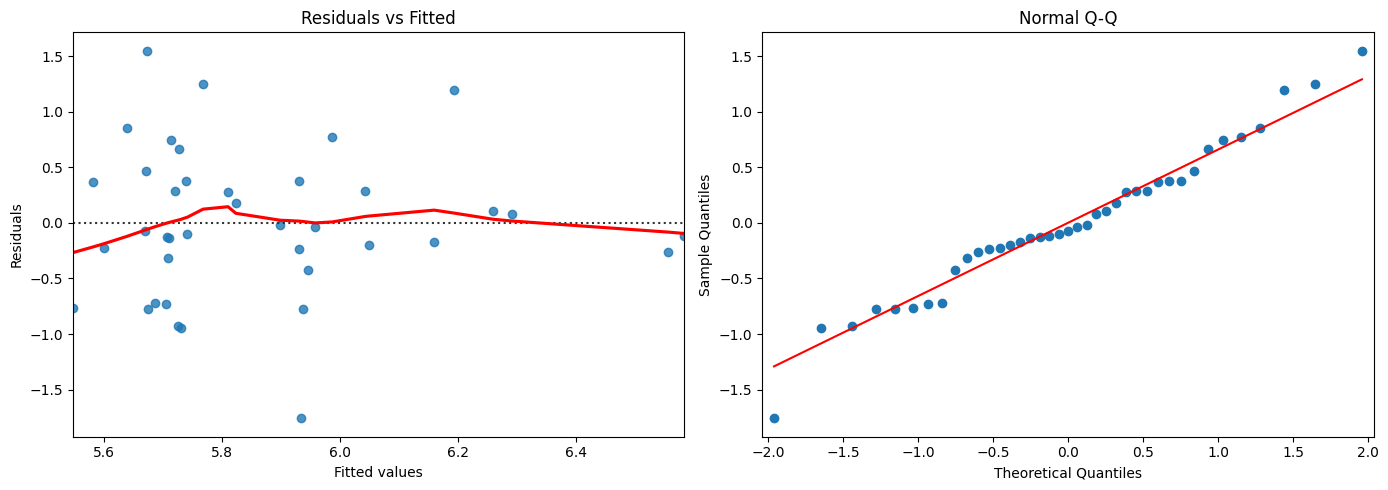

In [14]:
# 3.2 Linear Regression (OLS)
formula_ols = "grd_mean_los ~ pct_foreign + mean_schooling_chilean + pct_unemployed + dependency_ratio"
ols_model = smf.ols(formula=formula_ols, data=df_mod).fit()
print(ols_model.summary())

# 3.3 Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
sns.residplot(x=ols_model.fittedvalues, y=ols_model.resid, lowess=True, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

# QQ Plot
sm.qqplot(ols_model.resid, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q')

plt.tight_layout()
plt.show()

## Part 4: Ecological Fallacy
El modelamiento ecológico presenta desafíos interpretativos fundamentales que deben abordarse antes de extraer conclusiones en salud pública.

**1.Asociación individual vs. ecológica:** La diferencia central radica en la unidad de análisis. Una asociación a nivel individual afirma que una característica personal (ej. ser extranjero) aumenta la probabilidad de un resultado específico en *esa misma persona*.Por el contrario, una asociación ecológica establece que comunas con altas proporciones de una característica tienen altas tasas de un resultado. No podemos deducir causalidad a nivel micro a partir de datos agregados a nivel macro.

**2.Ejemplo concreto de mala interpretación:** En nuestro modelo, si encontramos un coeficiente significativo y negativo entre `pct_foreign` y `eno_rate_per_10k`, una interpretación falaz (falacia ecológica de Robinson) sería afirmar que "las personas extranjeras se enferman menos o evitan los hospitales". La realidad podría ser completamente distinta: quizás los migrantes se concentran en comunas con menos dotación hospitalaria, o tal vez son los residentes chilenos de *esas comunas específicas* quienes reportan menos notificaciones. El dato agrupado no distingue quién es el paciente.

**3.Utilidad para la planificación en Salud Pública:** A pesar de esto, las asociaciones ecológicas son extremadamente valiosas. Si descubrimos que el porcentaje de desempleo (`pct_unemployed`) predice un mayor conteo de hospitalizaciones (GRD) a nivel comunal, esto justifica la reasignación de fondos y camas a hospitales ubicados en zonas con alto desempleo. Para la política pública, no importa si el paciente individual hospitalizado está desempleado o no; lo que importa es que *la zona geográfica* requerirá más recursos.

**4.Amenazas adicionales a la inferencia:** Un problema no abordado en nuestros modelos OLS/Poisson es la autocorrelación espacial. Las comunas no son islas independientes; una crisis epidemiológica o de hacinamiento en Estación Central afectará directamente a Santiago Centro. Asumir independencia de los errores (como hace OLS) subestima la varianza real. En trabajos futuros, esto debería abordarse mediante modelos de rezago espacial (Spatial Lag/Error Models) o incorporando efectos aleatorios espaciales en la regresión.

## Part 5: Spatial Visualization of Model Output
[cite_start]Visualización de los resultados del modelo Binomial Negativo para ENO[cite: 118].

Error cargando mapa: Unable to open comunas.shx or comunas.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.


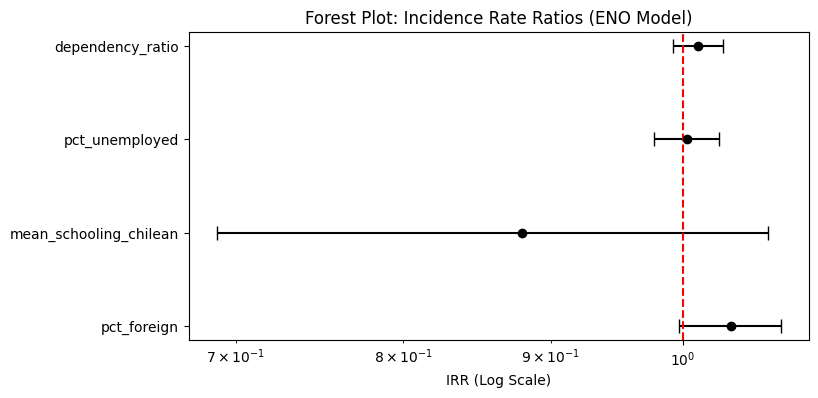

In [15]:
# Cargar geometría
try:
    gdf = gpd.read_file("comunas.shp")

    # Buscador implacable de la columna de códigos (sin importar mayúsculas/minúsculas)
    nombres_posibles = ['CUT', 'COD_COMUNA', 'cod_comuna', 'codigo_comuna', 'COMUNA', 'comuna', 'Cod_Comuna']
    for col in nombres_posibles:
        if col in gdf.columns:
            gdf['codigo_comuna'] = pd.to_numeric(gdf[col], errors='coerce')
            break

    # Calcular predicciones y residuos de Pearson
    df_mod['predicted_eno_rate'] = (nb_eno.predict() / df_mod['pop_total']) * 10000
    df_mod['pearson_resid'] = nb_eno.resid_pearson

    gdf_merged = gdf.merge(df_mod, on='codigo_comuna', how='inner')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # 5.1 Predicted Rate Map
    gdf_merged.plot(column='predicted_eno_rate', cmap='viridis', legend=True, ax=axes[0], edgecolor='black')
    axes[0].set_title('Tasa Predicha ENO (por 10,000 hab)')
    axes[0].axis('off')

    # 5.2 Residual Map
    gdf_merged.plot(column='pearson_resid', cmap='coolwarm', legend=True, ax=axes[1], edgecolor='black')
    axes[1].set_title('Residuos de Pearson (Modelo Binomial Negativo)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error cargando mapa: {e}")
    if 'gdf' in locals():
        print(f"⚠️ Las columnas que realmente tiene tu archivo de mapa son: {gdf.columns.tolist()}")

# 5.3 Coefficient Plot (Forest Plot)
err = np.exp(nb_eno.params) - np.exp(nb_eno.conf_int()[0])
coefs = pd.DataFrame({'coef': np.exp(nb_eno.params), 'err': err})
coefs = coefs.drop('Intercept') # Remover intercepto para mejor escala

plt.figure(figsize=(8, 4))
plt.errorbar(x=coefs['coef'], y=coefs.index, xerr=coefs['err'], fmt='o', color='black', capsize=5)
plt.axvline(x=1, color='red', linestyle='--') # Null para IRR es 1
plt.xscale('log')
plt.title('Forest Plot: Incidence Rate Ratios (ENO Model)')
plt.xlabel('IRR (Log Scale)')
plt.show()

## Part 6: Integrated Synthesis

Este estudio ecológico integra datos del Censo, el registro de Enfermedades de Notificación Obligatoria (ENO) y los Grupos Relacionados de Diagnóstico (GRD) para analizar cómo la composición sociodemográfica modela el perfil de interacciones con el sistema de salud en la Región Metropolitana.

**1. El Retrato Demográfico de la Región Metropolitana (Tarea 1):**
El paisaje demográfico de la RM es profundamente heterogéneo y espacialmente segregado. A nivel de comuna, el eje dominante de variación es claramente socioeconómico. Las matrices de correlación y los diagramas de dispersión evidencian un patrón consolidado donde la alta escolaridad y las bajas tasas de dependencia convergen en el cono nororiente de la capital, mientras que comunas periféricas absorben mayores niveles de desempleo y mayores proporciones de población migrante, reflejando un desarrollo urbano desigual.

**2. El Mapeo del Paisaje de Salud (Tarea 2):**
Al superponer los resultados de salud sobre este eje sociodemográfico, encontramos un panorama complejo de coincidencias y desacoples. Se observan "matches" esperables: las comunas con indicadores de vulnerabilidad sociodemográfica muestran tasas base alteradas en sus cargas de GRD. Sin embargo, los "mismatches" son igualmente reveladores. Ciertas comunas actúan como *outliers* masivos (como vimos en los mapas de calor y residuos), no necesariamente por un deterioro intrínseco de su población, sino por la distribución geográfica de los hospitales base. Comunas céntricas como Independencia muestran tasas de notificación infladas debido a la absorción de población flotante y derivaciones inter-comunales, enmascarando las verdaderas tasas de incidencia local.

**3. El Valor Añadido de los Modelos Cruzados (Tarea 3):**
La verdadera profundidad de este análisis emerge en los modelos de regresión. Si dependiéramos exclusivamente de una matriz de correlación (donde todo parece relacionarse con todo), ignoraríamos el peso relativo de los factores. Los modelos de regresión de conteo (Binomial Negativa, utilizando la población como *offset*) permiten estandarizar la exposición poblacional y revelar efectos puros. Un hallazgo que no habría sido obvio desde un solo conjunto de datos es cómo, al controlar por el tamaño poblacional y variables estructurales (como la brecha educativa), factores demográficos como el porcentaje de inmigración (`pct_foreign`) retienen poder explicativo sobre la carga hospitalaria, arrojando luz sobre potenciales brechas de acceso preventivo que obligan a estas poblaciones a utilizar los recintos de alta complejidad.

En conclusión, la triangulación de estos tres conjuntos de datos confirma que la demografía comunal es un fuerte predictor de la saturación del sistema de salud, aunque la interpretación de estos datos agregados exige cautela debido a la falacia ecológica. La evidencia respalda la necesidad de focalizar el financiamiento hospitalario no solo en función de la población total, sino ajustado por los determinantes sociodemográficos estructurales de cada territorio.